<a href="https://colab.research.google.com/github/Fakhar001/AIC354-Machine-Learning-Fundamentals/blob/main/ML_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression: A Classification Algorithm

Logistic Regression is a powerful and widely used supervised learning algorithm for **binary classification problems**. Despite its name, it's used for predicting categorical outcomes (like 'yes' or 'no', 'true' or 'false', 'churn' or 'no churn'), rather than continuous numerical values like traditional regression models.

The core idea is to estimate the probability that an instance belongs to a particular class. It does this by applying a **sigmoid function** (also known as the logistic function) to a linear combination of input features. The sigmoid function squashes any real-valued number into a value between 0 and 1, which can then be interpreted as a probability.

### Why Logistic Regression for Classification?

*   **Probabilistic Output**: It provides probabilities, which can be useful for understanding the certainty of a prediction.
*   **Interpretability**: The coefficients of the model can often be interpreted to understand the impact of each feature on the outcome.
*   **Efficiency**: It's computationally efficient and works well on linearly separable data.

### Case Study: Titanic Survival Prediction

**Problem Statement:** We want to predict whether a passenger survived the Titanic shipwreck based on features like their age, passenger class, sex, and fare. This is a classic binary classification problem where the target variable is 'Survived' (1 for survived, 0 for not survived).

**Dataset Features:**
*   `PassengerId`: Unique ID for each passenger.
*   `Survived`: Survival (0 = No, 1 = Yes) - **Target Variable**
*   `Pclass`: Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)
*   `Name`: Passenger's name.
*   `Sex`: Sex (male/female).
*   `Age`: Age in years.
*   `SibSp`: Number of siblings/spouses aboard the Titanic.
*   `Parch`: Number of parents/children aboard the Titanic.
*   `Ticket`: Ticket number.
*   `Fare`: Passenger fare.
*   `Cabin`: Cabin number.
*   `Embarked`: Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

# Load the Titanic dataset from a public URL (or use seaborn.load_dataset('titanic'))
titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("First 5 rows of the Titanic dataset:")
display(titanic_df.head())

print("\nDataset Information:")
display(titanic_df.info())

print("\nMissing values:")
display(titanic_df.isnull().sum())

First 5 rows of the Titanic dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None


Missing values:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### 1. Data Exploration and Preparation

Before building the model, it's crucial to understand the data, handle missing values, and prepare features for the algorithm. We'll perform basic exploration and then preprocess the data.

In [2]:
# Drop irrelevant features for this basic model
titanic_df = titanic_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Handle missing 'Age' values by filling with the median
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)

# Handle missing 'Embarked' values by filling with the most frequent value (mode)
titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0], inplace=True)

print("\nMissing values after imputation:")
display(titanic_df.isnull().sum())

print("\nUpdated Dataset Information:")
display(titanic_df.info())


Missing values after imputation:


/tmp/ipykernel_7831/4247630386.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)
/tmp/ipykernel_7831/4247630386.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0



Updated Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


None

### 2. Feature Engineering and Preprocessing Pipeline

We need to convert categorical features into a numerical format that the model can understand and scale numerical features to prevent features with larger values from dominating the learning process. A `ColumnTransformer` and `Pipeline` will streamline these steps.

*   **Categorical Features:** `Sex`, `Embarked`, `Pclass` will be One-Hot Encoded.
*   **Numerical Features:** `Age`, `SibSp`, `Parch`, `Fare` will be Standard Scaled.
*   **Target Variable:** `Survived`.

In [3]:
# Separate features (X) and target (y)
X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

# Define categorical and numerical features
categorical_features = ['Sex', 'Embarked']
numerical_features = ['Age', "Pclass",'SibSp', 'Parch', 'Fare']

# Create a column transformer for preprocessing
# One-Hot Encode categorical features and Standard Scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (712, 7)
y_train shape: (712,)
X_test shape: (179, 7)
y_test shape: (179,)


### 3. Model Training

Now, we'll build a `Pipeline` that first applies the preprocessing steps (using the `preprocessor` defined above) and then trains a `LogisticRegression` model on the preprocessed data.

In [4]:
# Create a pipeline that first preprocesses the data then applies Logistic Regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear')) # liblinear is good for small datasets and handles L1/L2 regularization
])

# Train the model
model_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully on Titanic data!")

Logistic Regression model trained successfully on Titanic data!


### 4. Prediction

After training, we use the model to make predictions on the `X_test` dataset. We'll predict both the class labels (0 or 1 for survival) and the probabilities of survival.

In [29]:
# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class (Survived=1)

print("First 10 predicted class labels (0=No Survival, 1=Survival):")
display(y_pred[:10])

print("\nFirst 10 predicted probabilities for Survival:")
display(y_pred_proba[:10])

First 10 predicted class labels (0=No Survival, 1=Survival):


array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0])


First 10 predicted probabilities for Survival:


array([0.06780395, 0.04823549, 0.15645126, 0.03612646, 0.67186598,
       0.44118544, 0.76686132, 0.30613534, 0.34446392, 0.17510069])

### 5. Evaluation Metrics for Classification

Evaluating a classification model is crucial to understand its performance. Unlike regression, where metrics like MSE are common, classification uses a different set of metrics. We'll focus on:

*   **Confusion Matrix**: A table that summarizes the performance of a classification algorithm. It shows the number of correct and incorrect predictions made by a classifier compared to the actual outcomes (target values).
    *   **True Positive (TP)**: Actual `1` predicted as `1`.
    *   **True Negative (TN)**: Actual `0` predicted as `0`.
    *   **False Positive (FP)**: Actual `0` predicted as `1` (Type I error).
    *   **False Negative (FN)**: Actual `1` predicted as `0` (Type II error).

*   **Accuracy**: The ratio of correctly predicted observations to the total observations.
    $\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$

*   **Precision**: The ratio of correctly predicted positive observations to the total predicted positive observations. It answers: "Of all instances predicted as positive, how many were actually positive?"
    $\text{Precision} = \frac{TP}{TP + FP}$

*   **Recall (Sensitivity or True Positive Rate)**: The ratio of correctly predicted positive observations to all observations in the actual class. It answers: "Of all actual positive instances, how many did we correctly predict?"
    $\text{Recall} = \frac{TP}{TP + FN}$

*   **F1-Score**: The harmonic mean of Precision and Recall. It tries to find the balance between precision and recall, and is a good measure for imbalanced datasets.
    $\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

*   **ROC Curve (Receiver Operating Characteristic)**: A plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.
    *   It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various threshold settings.
    *   TPR = Recall
    *   FPR = FP / (FP + TN)

*   **AUC (Area Under the ROC Curve)**: This is the area under the ROC curve. A single scalar value that summarizes the overall performance of a classification model across all possible classification thresholds.
    *   **Interpretation**: It represents the probability that the model ranks a randomly chosen positive instance higher than a randomly chosen negative instance.
    *   **AUC = 1**: Perfect classifier.
    *   **AUC = 0.5**: Equivalent to random guessing.
    *   **AUC < 0.5**: Worse than random guessing.

#### Confusion Matrix Visualization

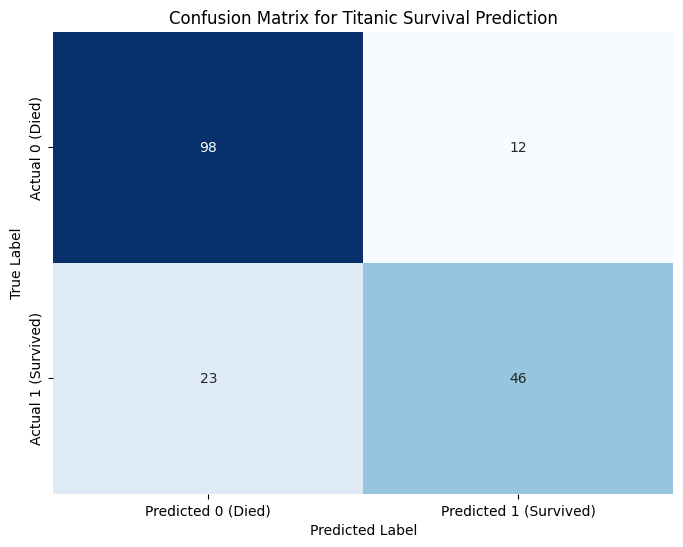

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Died)', 'Predicted 1 (Survived)'],
            yticklabels=['Actual 0 (Died)', 'Actual 1 (Survived)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Titanic Survival Prediction')
plt.show()

#### Classification Report (Accuracy, Precision, Recall, F1-Score)

In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Extract individual metrics for clarity
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Precision (Class 1 - Survived): {precision:.4f}")
print(f"Recall (Class 1 - Survived): {recall:.4f}")
print(f"F1-Score (Class 1 - Survived): {f1:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Overall Accuracy: 0.8045
Precision (Class 1 - Survived): 0.7931
Recall (Class 1 - Survived): 0.6667
F1-Score (Class 1 - Survived): 0.7244


#### ROC Curve and AUC Score

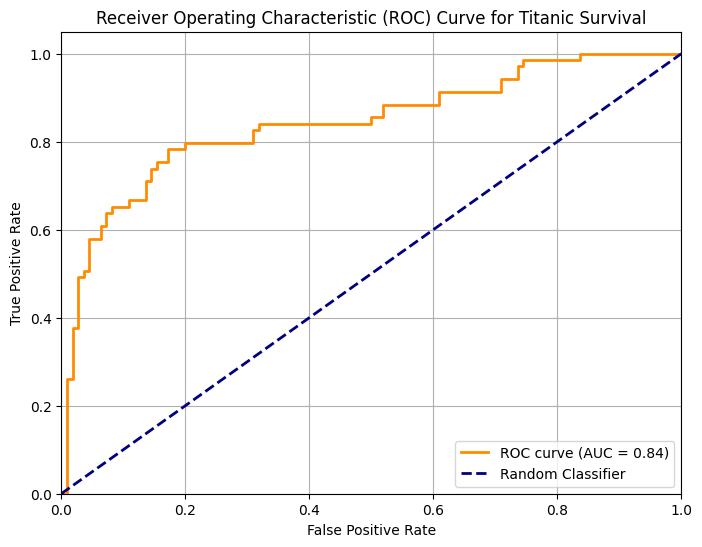

Area Under the Curve (AUC): 0.8432


In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Titanic Survival')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")

### Conclusion

In this lesson, we successfully built and evaluated a Logistic Regression model to predict Titanic survival. We covered:

1.  **Data Loading & Initial Exploration**: Understanding the dataset and its features.
2.  **Data Preprocessing**: Handling missing values (`Age`, `Embarked`), dropping irrelevant columns, and preparing features using `ColumnTransformer` (One-Hot Encoding for categorical, Standard Scaling for numerical).
3.  **Model Training**: Building a `Pipeline` to encapsulate preprocessing and model training with `LogisticRegression`.
4.  **Prediction**: Generating class predictions and survival probabilities on unseen test data.
5.  **Evaluation Metrics**: Deep diving into the Confusion Matrix, Accuracy, Precision, Recall, F1-Score, and the ROC AUC curve to thoroughly assess the model's performance.

This demonstrates a complete workflow for solving a binary classification problem using Logistic Regression on a real-world dataset.

## Decision Tree: A Versatile Classification Algorithm

Decision Trees are non-parametric supervised learning algorithms used for both classification and regression tasks. For classification, they build a model in the form of a tree structure, where each internal node represents a 'test' on an attribute (e.g., 'Is Age <= 10?'), each branch represents the outcome of the test, and each leaf node represents a class label (the decision taken after computing all attributes).

### How Decision Trees Work (Briefly for Classification):

1.  **Splitting**: The algorithm starts with a single node (the root) containing all data. It then looks for the best feature to split the data into subsets. The 'best' split is determined by criteria like Gini impurity or Information Gain, aiming to create child nodes that are as 'pure' as possible (i.e., contain samples predominantly from one class).
2.  **Recursive Process**: This splitting process is applied recursively to each child node, creating new branches and nodes.
3.  **Stopping Criteria**: The tree grows until a stopping criterion is met, such as:
    *   All samples in a node belong to the same class.
    *   A maximum depth is reached.
    *   The number of samples in a node falls below a minimum threshold.

### Why Decision Trees for Classification?

*   **Interpretability**: Decision trees are very easy to understand and visualize, often resembling human decision-making processes.
*   **No Feature Scaling Needed**: They are not sensitive to the scale of features.
*   **Can Handle Non-linear Relationships**: They can capture complex non-linear relationships between features and the target.
*   **Handles Mixed Data Types**: Can work with both numerical and categorical features.

### Case Study: Titanic Survival Prediction (Revisited with Decision Tree)

We will continue to use the Titanic survival prediction dataset to demonstrate the Decision Tree classifier. The goal remains the same: predict whether a passenger survived based on available features. This will allow for a direct comparison with the Logistic Regression model's performance.

### 1. Data Preparation (Using Already Processed Data)

For this Decision Tree lesson, we will reuse the `X_train`, `X_test`, `y_train`, and `y_test` datasets that were prepared during the Logistic Regression lesson. The preprocessing steps (handling missing values, one-hot encoding, and standard scaling) are already applied via the `preprocessor` `ColumnTransformer` within the `Pipeline`.

In [9]:
from sklearn.tree import DecisionTreeClassifier

print("Reusing preprocessed data from previous steps.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Reusing preprocessed data from previous steps.
X_train shape: (712, 7)
y_train shape: (712,)
X_test shape: (179, 7)
y_test shape: (179,)


### 2. Model Training (Decision Tree)

Now, we'll build a `Pipeline` similar to before, but this time replacing the `LogisticRegression` classifier with a `DecisionTreeClassifier`. We'll use the same `preprocessor` for consistency, although Decision Trees do not strictly require feature scaling.

In [10]:
# Create a pipeline that first preprocesses the data then applies a Decision Tree Classifier
dt_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5)) # max_depth to prevent overfitting
])

# Train the Decision Tree model
dt_model_pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully on Titanic data!")

Decision Tree model trained successfully on Titanic data!


### 3. Prediction (Decision Tree)

We will now use the trained Decision Tree model to make predictions (class labels and probabilities) on the test set.

In [11]:
# Make predictions on the test set using the Decision Tree
dt_y_pred = dt_model_pipeline.predict(X_test)
dt_y_pred_proba = dt_model_pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class (Survived=1)

print("First 10 predicted class labels (Decision Tree):")
display(dt_y_pred[:10])

print("\nFirst 10 predicted probabilities for Survival (Decision Tree):")
display(dt_y_pred_proba[:10])

First 10 predicted class labels (Decision Tree):


array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0])


First 10 predicted probabilities for Survival (Decision Tree):


array([0.11003236, 0.11003236, 0.11003236, 0.11003236, 0.63157895,
       0.09090909, 0.92307692, 0.61538462, 0.30909091, 0.11003236])

### 4. Evaluation Metrics for Decision Tree Classification

We will use the same evaluation metrics as before to assess the performance of the Decision Tree model: Confusion Matrix, Classification Report (Accuracy, Precision, Recall, F1-Score), and the ROC AUC curve.

#### Confusion Matrix Visualization (Decision Tree)

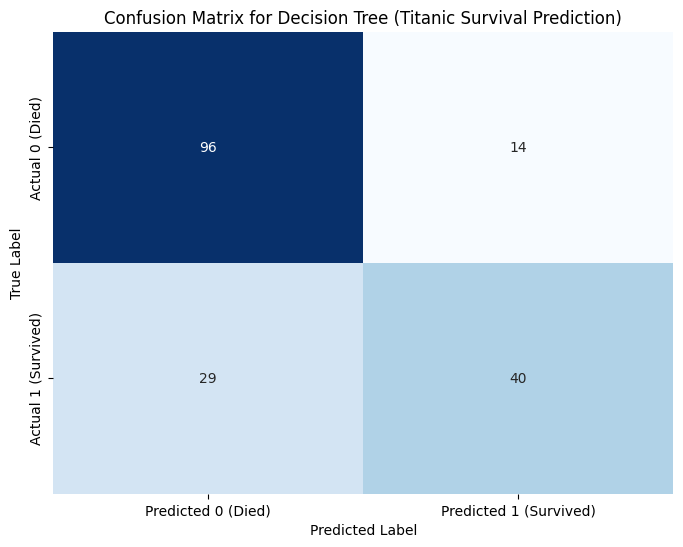

In [12]:
dt_cm = confusion_matrix(y_test, dt_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Died)', 'Predicted 1 (Survived)'],
            yticklabels=['Actual 0 (Died)', 'Actual 1 (Survived)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree (Titanic Survival Prediction)')
plt.show()

#### Classification Report (Accuracy, Precision, Recall, F1-Score) for Decision Tree

In [13]:
print("Classification Report (Decision Tree):")
print(classification_report(y_test, dt_y_pred))

# Extract individual metrics for clarity
dt_accuracy = accuracy_score(y_test, dt_y_pred)
dt_precision = precision_score(y_test, dt_y_pred)
dt_recall = recall_score(y_test, dt_y_pred)
dt_f1 = f1_score(y_test, dt_y_pred)

print(f"\nOverall Accuracy (Decision Tree): {dt_accuracy:.4f}")
print(f"Precision (Class 1 - Survived, Decision Tree): {dt_precision:.4f}")
print(f"Recall (Class 1 - Survived, Decision Tree): {dt_recall:.4f}")
print(f"F1-Score (Class 1 - Survived, Decision Tree): {dt_f1:.4f}")

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       110
           1       0.74      0.58      0.65        69

    accuracy                           0.76       179
   macro avg       0.75      0.73      0.73       179
weighted avg       0.76      0.76      0.75       179


Overall Accuracy (Decision Tree): 0.7598
Precision (Class 1 - Survived, Decision Tree): 0.7407
Recall (Class 1 - Survived, Decision Tree): 0.5797
F1-Score (Class 1 - Survived, Decision Tree): 0.6504


#### ROC Curve and AUC Score (Decision Tree)

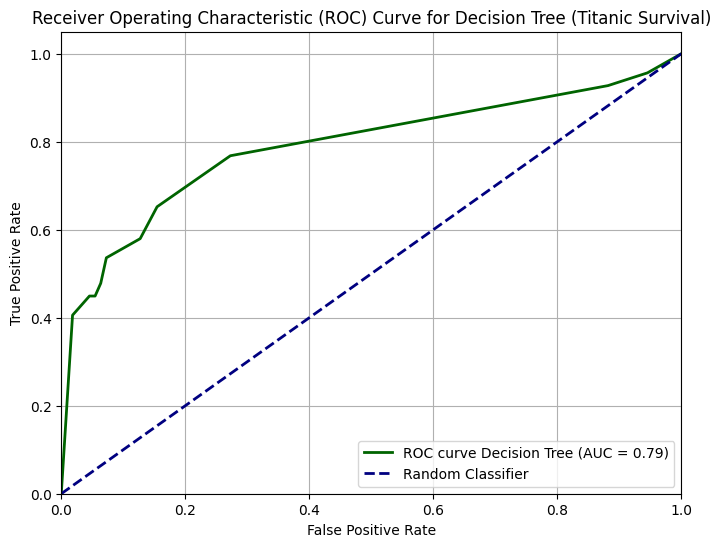

Area Under the Curve (AUC) for Decision Tree: 0.7891


In [14]:
dt_fpr, dt_tpr, dt_thresholds = roc_curve(y_test, dt_y_pred_proba)
dt_roc_auc = roc_auc_score(y_test, dt_y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(dt_fpr, dt_tpr, color='darkgreen', lw=2, label=f'ROC curve Decision Tree (AUC = {dt_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree (Titanic Survival)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC) for Decision Tree: {dt_roc_auc:.4f}")

### Conclusion (Decision Tree)

In this lesson, we explored the Decision Tree algorithm for the Titanic survival prediction task. We covered:

1.  **Introduction to Decision Trees**: Understanding their structure and how they make classifications.
2.  **Model Training**: Building a `Pipeline` with a `DecisionTreeClassifier`.
3.  **Prediction**: Making class and probability predictions on the test set.
4.  **Evaluation Metrics**: Assessing performance using Confusion Matrix, Classification Report, and ROC AUC.

Decision Trees offer great interpretability and can handle various data types. However, a single decision tree can be prone to overfitting, especially if it grows too deep. Techniques like pruning or ensemble methods (e.g., Random Forests, Gradient Boosting) are often used to mitigate this. Comparing its performance metrics with Logistic Regression provides insights into which model might be more suitable for a given problem or if a more complex model is warranted.

# Naive Bayes Classifier: A Probabilistic Approach
Naive Bayes classifiers are a family of simple probabilistic classifiers based on applying Bayes' theorem with strong (naive) independence assumptions between the features. Despite these strong assumptions, Naive Bayes classifiers have worked quite well in many complex real-world situations, especially for text classification and spam detection.

How Naive Bayes Works (for Classification):
Bayes' Theorem: The core of the classifier is Bayes' theorem, which calculates the probability of a hypothesis (a class) given some evidence (features): $P(A|B) = \frac{P(B|A) P(A)}{P(B)}$ In our case, $P(\text{class}|\text{features}) = \frac{P(\text{features}|\text{class}) P(\text{class})}{P(\text{features})}$

"Naive" Assumption: The key assumption is that all features are independent of each other given the class. This simplifies the calculation of $P(\text{features}|\text{class})$$P(\text{features}|\text{class})$.

Classification: For a new data point, the classifier calculates the posterior probability for each class and assigns the data point to the class with the highest probability.

Types of Naive Bayes:
Gaussian Naive Bayes: Used when features are continuous and assumed to follow a Gaussian (normal) distribution.
Multinomial Naive Bayes: Suitable for discrete counts, often used in text classification (e.g., word counts).
Bernoulli Naive Bayes: Designed for binary/boolean features.
Why Naive Bayes for Classification?
Simplicity and Speed: It's very easy to implement and computationally efficient.
Works well with small datasets: Can perform surprisingly well even with limited training data.
Scalability: It scales well with the number of features and data points.
Handles high-dimensional data: Particularly effective in cases with many features.

In [16]:
from sklearn.naive_bayes import GaussianNB

print("Reusing preprocessed data from previous steps.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Reusing preprocessed data from previous steps.
X_train shape: (712, 7)
y_train shape: (712,)
X_test shape: (179, 7)
y_test shape: (179,)


### 2. Model Training (Naive Bayes)

We'll create another `Pipeline` that first applies the `preprocessor` and then uses a `GaussianNB` classifier. Although Naive Bayes doesn't strictly require scaling, it's good practice to keep the preprocessing consistent for fair comparison.


In [17]:
# Create a pipeline that first preprocesses the data then applies a Gaussian Naive Bayes Classifier
nb_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

# Train the Naive Bayes model
nb_model_pipeline.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully on Titanic data!")

Gaussian Naive Bayes model trained successfully on Titanic data!


### 3. Prediction (Naive Bayes)

Now, we'll use the trained Naive Bayes model to make predictions (class labels and probabilities) on the test set.


In [18]:
# Make predictions on the test set using the Naive Bayes model
nb_y_pred = nb_model_pipeline.predict(X_test)
nb_y_pred_proba = nb_model_pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class (Survived=1)

print("First 10 predicted class labels (Naive Bayes):")
display(nb_y_pred[:10])

print("\nFirst 10 predicted probabilities for Survival (Naive Bayes):")
display(nb_y_pred_proba[:10])

First 10 predicted class labels (Naive Bayes):


array([0, 0, 0, 0, 1, 1, 1, 0, 1, 0])


First 10 predicted probabilities for Survival (Naive Bayes):


array([6.31999319e-04, 3.23844026e-03, 7.07458647e-02, 5.29305029e-04,
       9.81936299e-01, 7.89040932e-01, 9.71407165e-01, 1.55706538e-01,
       9.95735508e-01, 2.11604054e-02])

### 4. Evaluation Metrics for Naive Bayes Classification

We will use the standard evaluation metrics to assess the performance of the Naive Bayes model: Confusion Matrix, Classification Report (Accuracy, Precision, Recall, F1-Score), and the ROC AUC curve.

#### Confusion Matrix Visualization (Naive Bayes)


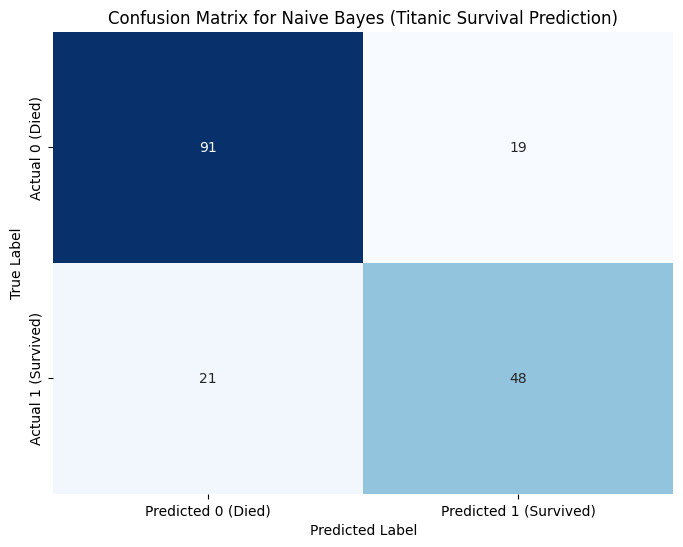

In [19]:
nb_cm = confusion_matrix(y_test, nb_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Died)', 'Predicted 1 (Survived)'],
            yticklabels=['Actual 0 (Died)', 'Actual 1 (Survived)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Naive Bayes (Titanic Survival Prediction)')
plt.show()

#### Classification Report (Accuracy, Precision, Recall, F1-Score) for Naive Bayes


In [20]:
print("Classification Report (Naive Bayes):")
print(classification_report(y_test, nb_y_pred))

# Extract individual metrics for clarity
nb_accuracy = accuracy_score(y_test, nb_y_pred)
nb_precision = precision_score(y_test, nb_y_pred)
nb_recall = recall_score(y_test, nb_y_pred)
nb_f1 = f1_score(y_test, nb_y_pred)

print(f"\nOverall Accuracy (Naive Bayes): {nb_accuracy:.4f}")
print(f"Precision (Class 1 - Survived, Naive Bayes): {nb_precision:.4f}")
print(f"Recall (Class 1 - Survived, Naive Bayes): {nb_recall:.4f}")
print(f"F1-Score (Class 1 - Survived, Naive Bayes): {nb_f1:.4f}")

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.72      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179


Overall Accuracy (Naive Bayes): 0.7765
Precision (Class 1 - Survived, Naive Bayes): 0.7164
Recall (Class 1 - Survived, Naive Bayes): 0.6957
F1-Score (Class 1 - Survived, Naive Bayes): 0.7059


#### ROC Curve and AUC Score (Naive Bayes)


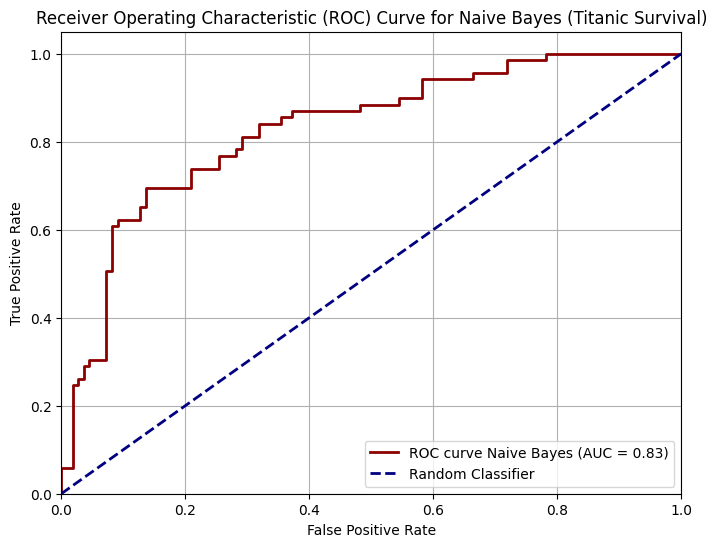

Area Under the Curve (AUC) for Naive Bayes: 0.8298


In [21]:
nb_fpr, nb_tpr, nb_thresholds = roc_curve(y_test, nb_y_pred_proba)
nb_roc_auc = roc_auc_score(y_test, nb_y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(nb_fpr, nb_tpr, color='darkred', lw=2, label=f'ROC curve Naive Bayes (AUC = {nb_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Naive Bayes (Titanic Survival)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC) for Naive Bayes: {nb_roc_auc:.4f}")

### Conclusion (Naive Bayes)

In this section, we applied the Gaussian Naive Bayes classifier to the Titanic survival prediction problem. We covered:

1.  **Introduction to Naive Bayes**: Understanding its probabilistic foundation and the "naive" independence assumption.
2.  **Model Training**: Building a `Pipeline` with a `GaussianNB` classifier.
3.  **Prediction**: Making class and probability predictions on the test set.
4.  **Evaluation Metrics**: Assessing performance using Confusion Matrix, Classification Report, and ROC AUC.

Comparing the results of Naive Bayes with Logistic Regression and Decision Tree reveals how different algorithmic assumptions impact performance on the same dataset. Naive Bayes, despite its simplicity, can offer competitive performance, especially when computational efficiency is a priority or when the independence assumption holds reasonably well. It's often a good baseline model due to its speed and ease of interpretation of feature importances (though not explicitly shown here, they are derived from the conditional probabilities).

## Support Vector Machines (SVM): A Powerful Classification Algorithm

Support Vector Machines (SVMs) are supervised learning models used for classification and regression tasks. In classification, SVM aims to find an optimal hyperplane that best separates data points of different classes in a high-dimensional space. The 'optimal' hyperplane is the one that has the largest margin (distance) to the nearest training data point of any class, which is known as the **support vectors**.

### How SVM Works (for Classification):

1.  **Hyperplane**: In a 2-D space, a hyperplane is a line. In a multi-dimensional space, it's a decision boundary that separates data points into different classes.
2.  **Margin**: The distance between the hyperplane and the nearest data point from each class. SVM seeks to maximize this margin.
3.  **Support Vectors**: The data points that are closest to the hyperplane and influence its position and orientation. These are the critical elements of the dataset.
4.  **Kernels**: For non-linearly separable data, SVM uses a 'kernel trick' to transform the input data into a higher-dimensional space where it can find a hyperplane. Common kernel functions include:
    *   **Linear**: For linearly separable data.
    *   **Polynomial**: For non-linear relationships.
    *   **Radial Basis Function (RBF) / Gaussian**: A popular choice for complex non-linear boundaries.
    *   **Sigmoid**: Another option for non-linear separation.

### Why SVM for Classification?

*   **Effective in High-Dimensional Spaces**: Works well even when the number of dimensions is greater than the number of samples.
*   **Memory Efficient**: Uses a subset of training points (support vectors) in the decision function.
*   **Versatile Kernel Functions**: Different kernel functions make it applicable to various types of data and decision boundaries.
*   **Robustness**: Can be less prone to overfitting than some other methods, especially with a good choice of kernel and regularization parameters.

### Case Study: Titanic Survival Prediction (with SVM)

We will continue with the Titanic survival prediction dataset to demonstrate the Support Vector Machine classifier. The goal remains to predict passenger survival based on available features, allowing for direct comparison with previous models.

### 1. Data Preparation (Using Already Processed Data)

We will reuse the `X_train`, `X_test`, `y_train`, and `y_test` datasets that were prepared and preprocessed (including standard scaling and one-hot encoding) in the earlier steps. This ensures a fair comparison across all models.

In [23]:
from sklearn.svm import SVC

print("Reusing preprocessed data from previous steps.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Reusing preprocessed data from previous steps.
X_train shape: (712, 7)
y_train shape: (712,)
X_test shape: (179, 7)
y_test shape: (179,)


### 2. Model Training (SVM)

We will now build a `Pipeline` that first applies the `preprocessor` (which includes scaling, crucial for SVMs) and then trains a `Support Vector Classifier (SVC)`. We'll use a `rbf` kernel, which is a common choice for non-linear decision boundaries.


In [24]:
# Create a pipeline that first preprocesses the data then applies a Support Vector Classifier
svm_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True)) # probability=True is needed for predict_proba and ROC curve
])

# Train the SVM model
svm_model_pipeline.fit(X_train, y_train)

print("Support Vector Machine model trained successfully on Titanic data!")

Support Vector Machine model trained successfully on Titanic data!


### 3. Prediction (SVM)

After training, we'll use the SVM model to make predictions (class labels and probabilities) on the test set.


In [25]:
# Make predictions on the test set using the SVM model
svm_y_pred = svm_model_pipeline.predict(X_test)
svm_y_pred_proba = svm_model_pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class (Survived=1)

print("First 10 predicted class labels (SVM):")
display(svm_y_pred[:10])

print("\nFirst 10 predicted probabilities for Survival (SVM):")
display(svm_y_pred_proba[:10])

First 10 predicted class labels (SVM):


array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0])


First 10 predicted probabilities for Survival (SVM):


array([0.09812728, 0.09179029, 0.18188497, 0.13704197, 0.84853235,
       0.46730783, 0.87921213, 0.16157474, 0.35848547, 0.13364851])

### 4. Evaluation Metrics for SVM Classification

We will use the standard evaluation metrics to assess the performance of the SVM model: Confusion Matrix, Classification Report (Accuracy, Precision, Recall, F1-Score), and the ROC AUC curve.

#### Confusion Matrix Visualization (SVM)


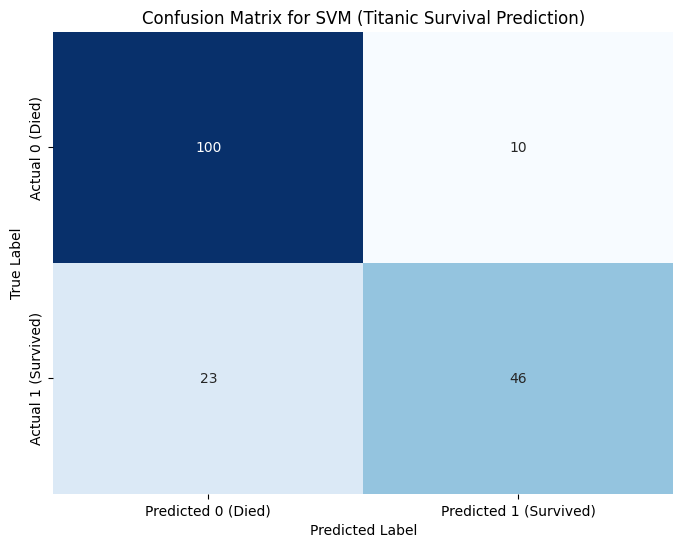

In [26]:
svm_cm = confusion_matrix(y_test, svm_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Died)', 'Predicted 1 (Survived)'],
            yticklabels=['Actual 0 (Died)', 'Actual 1 (Survived)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM (Titanic Survival Prediction)')
plt.show()

#### Classification Report (Accuracy, Precision, Recall, F1-Score) for SVM


In [27]:
print("Classification Report (SVM):")
print(classification_report(y_test, svm_y_pred))

# Extract individual metrics for clarity
svm_accuracy = accuracy_score(y_test, svm_y_pred)
svm_precision = precision_score(y_test, svm_y_pred)
svm_recall = recall_score(y_test, svm_y_pred)
svm_f1 = f1_score(y_test, svm_y_pred)

print(f"\nOverall Accuracy (SVM): {svm_accuracy:.4f}")
print(f"Precision (Class 1 - Survived, SVM): {svm_precision:.4f}")
print(f"Recall (Class 1 - Survived, SVM): {svm_recall:.4f}")
print(f"F1-Score (Class 1 - Survived, SVM): {svm_f1:.4f}")

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       110
           1       0.82      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179


Overall Accuracy (SVM): 0.8156
Precision (Class 1 - Survived, SVM): 0.8214
Recall (Class 1 - Survived, SVM): 0.6667
F1-Score (Class 1 - Survived, SVM): 0.7360


#### ROC Curve and AUC Score (SVM)


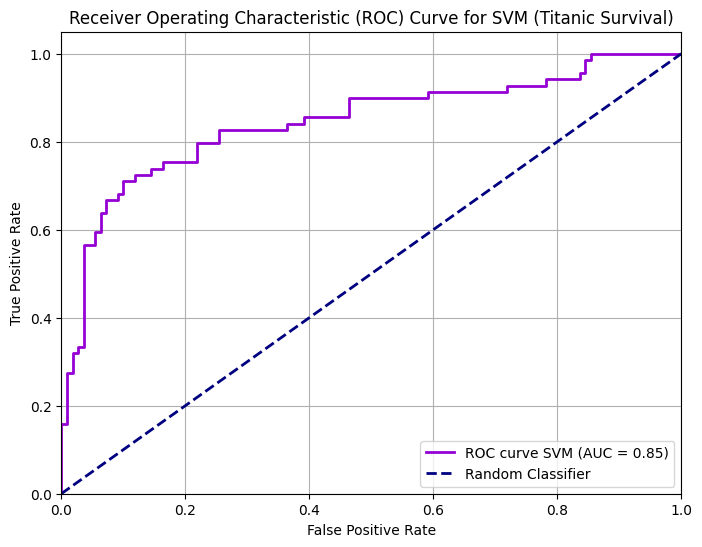

Area Under the Curve (AUC) for SVM: 0.8452


In [28]:
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_y_pred_proba)
svm_roc_auc = roc_auc_score(y_test, svm_y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(svm_fpr, svm_tpr, color='darkviolet', lw=2, label=f'ROC curve SVM (AUC = {svm_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM (Titanic Survival)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC) for SVM: {svm_roc_auc:.4f}")

### Conclusion (SVM)

In this section, we implemented and evaluated a Support Vector Machine (SVM) classifier for the Titanic survival prediction problem. We covered:

1.  **Introduction to SVM**: Understanding hyperplanes, margins, support vectors, and kernel functions.
2.  **Model Training**: Building a `Pipeline` with an `SVC` classifier, emphasizing the importance of preprocessing.
3.  **Prediction**: Generating class and probability predictions on the test set.
4.  **Evaluation Metrics**: Assessing performance using Confusion Matrix, Classification Report, and ROC AUC.

SVMs are robust and perform well in various scenarios, especially when a clear margin of separation exists or can be created through kernel tricks. Comparing its performance with Logistic Regression, Decision Trees, and Naive Bayes provides a comprehensive view of how different classification algorithms handle the same dataset.